<a href="https://www.kaggle.com/code/alaynac/transfer-learning-vgg16-intel-dataset?scriptVersionId=338894575" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

## Step 1A: Load Intel Image Classification Dataset

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
test_dir  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

CLASS_NAMES = list(train_ds.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print("Classes found:", CLASS_NAMES)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Step 1B: Visualize Sample Images

Display one example image from each of the 6 classes to understand
the dataset visually before training.

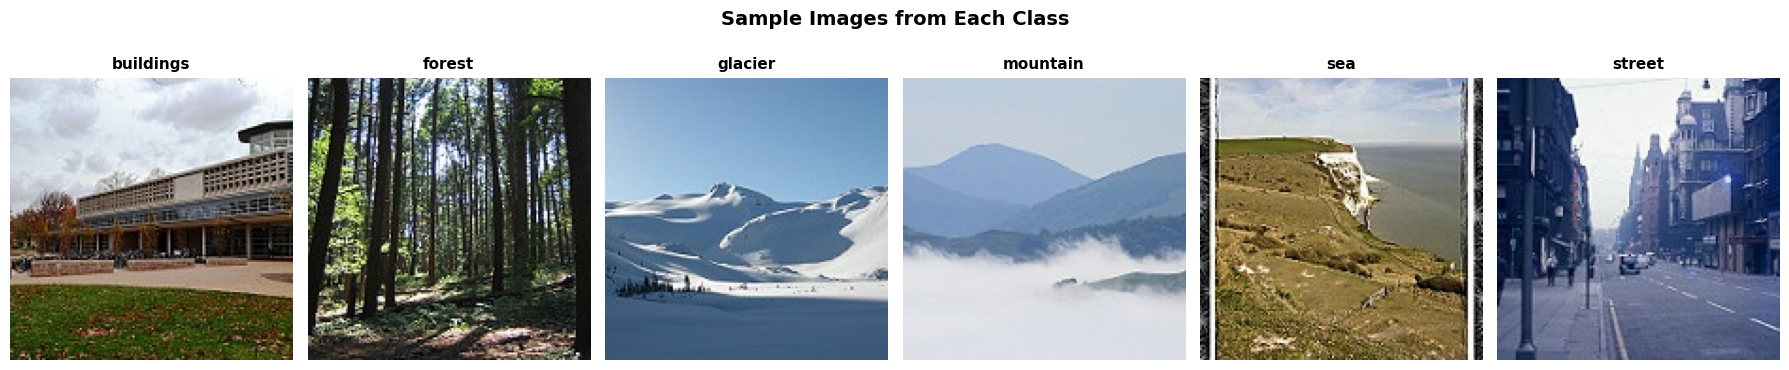

In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 4))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(train_dir, class_name)
    sample_image_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_image_name)
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('vgg16_sample_images.png')
plt.show()

## Step 2: Build VGG16 Transfer Learning Model

Load VGG16 pretrained on ImageNet, freeze its layers, and add a custom
classification head (Dense layers) on top for our 6 classes.

In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print(f"VGG16 base total layers: {len(base_model.layers)}")
print(f"VGG16 total params: {base_model.count_params():,}")

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='VGG16_TransferLearning')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1785352022.953698      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785352022.959750      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base total layers: 19
VGG16 total params: 14,714,688


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,214 (57.64 MB)

 Trainable params: 395,526 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 3: Train the Model

Train only the custom classification head while VGG16 base remains frozen.
Using EarlyStopping to prevent overfitting and ReduceLROnPlateau to
adjust learning rate automatically.

In [5]:
from tensorflow.keras import callbacks

EPOCHS = 10

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'vgg16_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/10
  2/439 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.2578 - loss: 7.9779   

I0000 00:00:1785352036.715379      86 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7776 - loss: 1.2167
Epoch 1: val_accuracy improved from None to 0.90633, saving model to vgg16_best.keras

Epoch 1: finished saving model to vgg16_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 134s 280ms/step - accuracy: 0.8293 - loss: 0.6957 - val_accuracy: 0.9063 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8787 - loss: 0.3407
Epoch 2: val_accuracy improved from 0.90633 to 0.90933, saving model to vgg16_best.keras

Epoch 2: finished saving model to vgg16_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 58s 131ms/step - accuracy: 0.8862 - loss: 0.3291 - val_accuracy: 0.9093 - val_loss: 0.2521 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9006 - loss: 0.2819
Epoch 3: val_accuracy improved from 0.90933 to 0.91133, saving model to vgg16_best.keras

Epoch 3: finished saving model to vgg16_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 56s 128ms

Best validation accuracy: 91.47% 

## Step 4: Visualize Training History

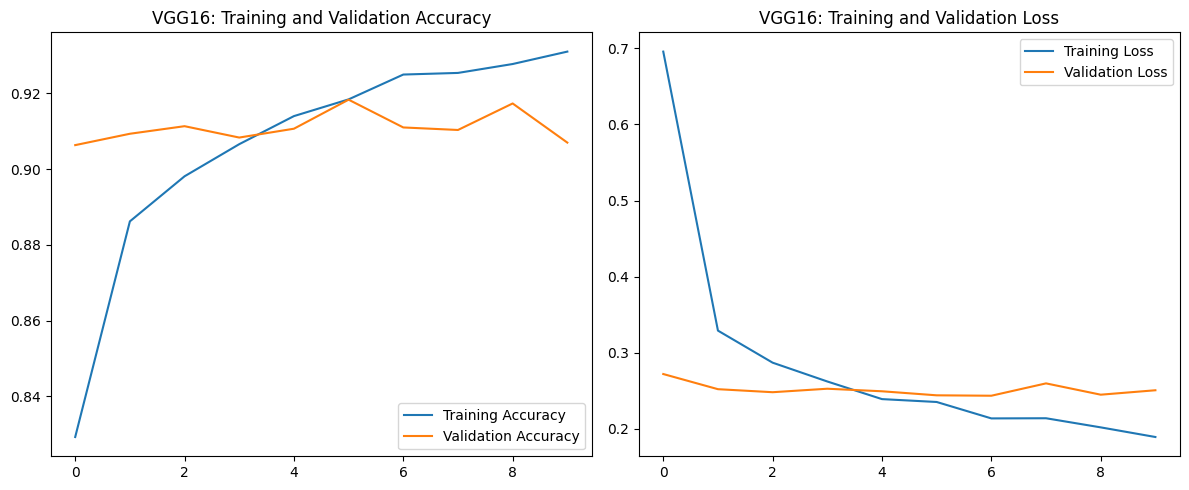

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('VGG16: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('VGG16: Training and Validation Loss')

plt.tight_layout()
plt.savefig('vgg16_training_history.png')
plt.show()

## Step 5: Model Evaluation - Confusion Matrix & Classification Report

Evaluate the final model on the test set and visualize which classes
are being confused with each other.

Found 3000 images belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step

Final Test Accuracy: 0.9183 (91.83%)
Final Test Loss: 0.2441

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.92      0.92       437
      forest       0.98      0.99      0.99       474
     glacier       0.85      0.88      0.86       553
    mountain       0.90      0.84      0.87       525
         sea       0.95      0.96      0.96       510
      street       0.93      0.93      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



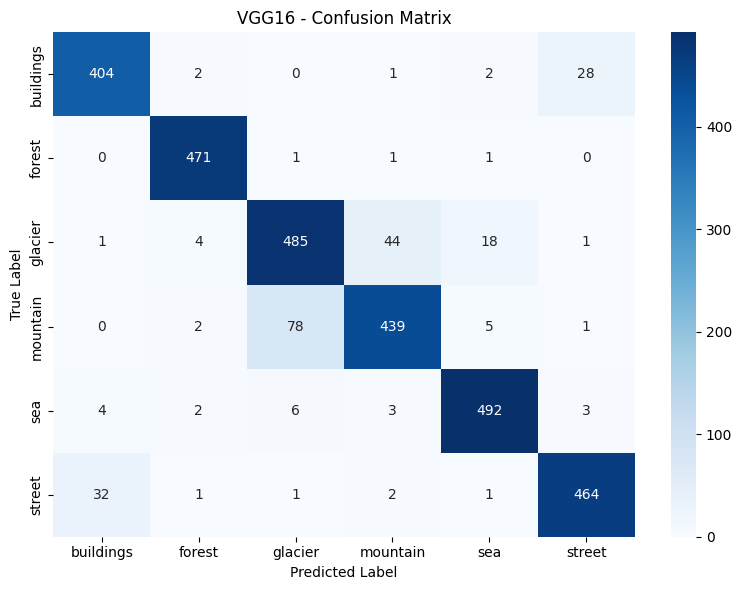

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
eval_ds = eval_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

y_pred_prob = model.predict(eval_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = eval_ds.classes

test_loss, test_acc = model.evaluate(eval_ds, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('VGG16 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix.png')
plt.show()

## Step 6: Live Demo - Predict on a New Image

Test the trained model on a new image to see it classify in real-time.

True label: street


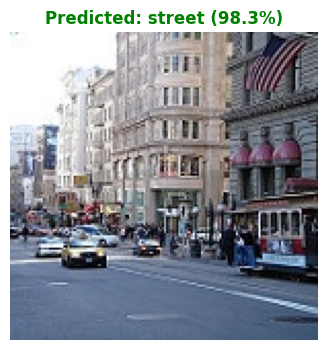

('street', np.float32(98.285126))

In [8]:
import random

def predict_image(img_path, model, class_names, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.1f}%)",
               fontsize=12, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

test_class = random.choice(CLASS_NAMES)
test_class_dir = os.path.join(test_dir, test_class)
random_image = random.choice(os.listdir(test_class_dir))
img_path = os.path.join(test_class_dir, random_image)

print(f"True label: {test_class}")
predict_image(img_path, model, CLASS_NAMES)

In [9]:
from IPython.display import FileLink
FileLink('vgg16_best.keras')

/kaggle/working/vgg16_best.keras